# 第146章: 世界モデル総括 — Phase 7の統合と未来展望

## World Models Synthesis: Integration of Phase 7 and Future Outlook

---

### このノートブックの位置づけ

Phase 7「世界モデル」シリーズの**総括**として、Notebook 140-145 で学んだ
全技術を俯瞰し、それらの関係性・共通点・相違点を整理します。
ピクセル空間予測・特徴空間予測（JEPA）・潜在行動空間（Genie）の
**3つのパラダイム**を比較し、世界モデルが AGI へとつながる道筋を展望します。

### 学習目標

この章を終えると、以下ができるようになります：

- [ ] Phase 7（Notebook 140-145）の技術体系を俯瞰し、各章の位置づけを説明できる
- [ ] ピクセル空間・特徴空間・潜在行動空間の3パラダイムを比較できる
- [ ] 各モデル（World Models, JEPA, Dreamer, Genie 等）のアーキテクチャ上の共通点と差異を説明できる
- [ ] Phase 1-7 の全カリキュラムの中で世界モデルの位置づけを把握できる
- [ ] 世界モデルから AGI への接続と、残された研究課題を理解できる

### 前提知識

- Notebook 140（予測のための表現学習）
- Notebook 141（Ha & Schmidhuber の World Models）
- Notebook 142（JEPA: Joint Embedding Predictive Architecture）
- Notebook 143（Dreamer: 潜在空間での想像と計画）
- Notebook 144（Genie: 潜在行動空間の発見）
- Notebook 145（世界モデルの評価指標）

**難易度**: ★★★★☆ | **所要時間**: 90-120分

## 目次

1. [環境セットアップ](#section1)
2. [Phase 7 の学習パス振り返り](#section2)
3. [3つのパラダイム比較: ピクセル / 特徴 / 潜在行動](#section3)
4. [アーキテクチャ比較チャート](#section4)
5. [全カリキュラム統合マップ (Phase 1-7)](#section5)
6. [AGI への接続と未来展望](#section6)
7. [総合クイズ（5問）](#quiz)
8. [まとめとチェックリスト](#summary)

---

<a id="section1"></a>
## 1. 環境セットアップ

In [1]:
# ============================================================
# 環境設定
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings

warnings.filterwarnings('ignore')
np.random.seed(146)

# 日本語フォント設定
def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_name = setup_japanese_font()
print(f'使用フォント: {font_name}')
print('Phase 7 総括ノートブックへようこそ！')

使用フォント: Yu Gothic
Phase 7 総括ノートブックへようこそ！


---

<a id="section2"></a>
## 2. Phase 7 の学習パス振り返り

Phase 7「世界モデル」では、**環境の内部モデルを構築し、未来を予測・想像する**ための
技術体系を6つのノートブック（140-145）で学びました。

| Notebook | テーマ | 核心技術 | 位置づけ |
|----------|--------|----------|----------|
| **140** | 予測のための表現学習 | 対照学習, t-SNE, 線形プローブ | **基盤** — 特徴空間予測の動機づけ |
| **141** | Ha & Schmidhuber World Models | VAE + MDN-RNN | **古典** — 世界モデルの原型 |
| **142** | JEPA | Joint Embedding, EMA Target | **理論** — 潜在空間予測のパラダイム |
| **143** | Dreamer | RSSM, 潜在想像 | **応用** — 強化学習への接続 |
| **144** | Genie | VQ-VAE, 潜在行動推定 | **発展** — 行動ラベルなしの学習 |
| **145** | 評価指標 | FVD, LPIPS, ATC | **評価** — 定量的な品質保証 |

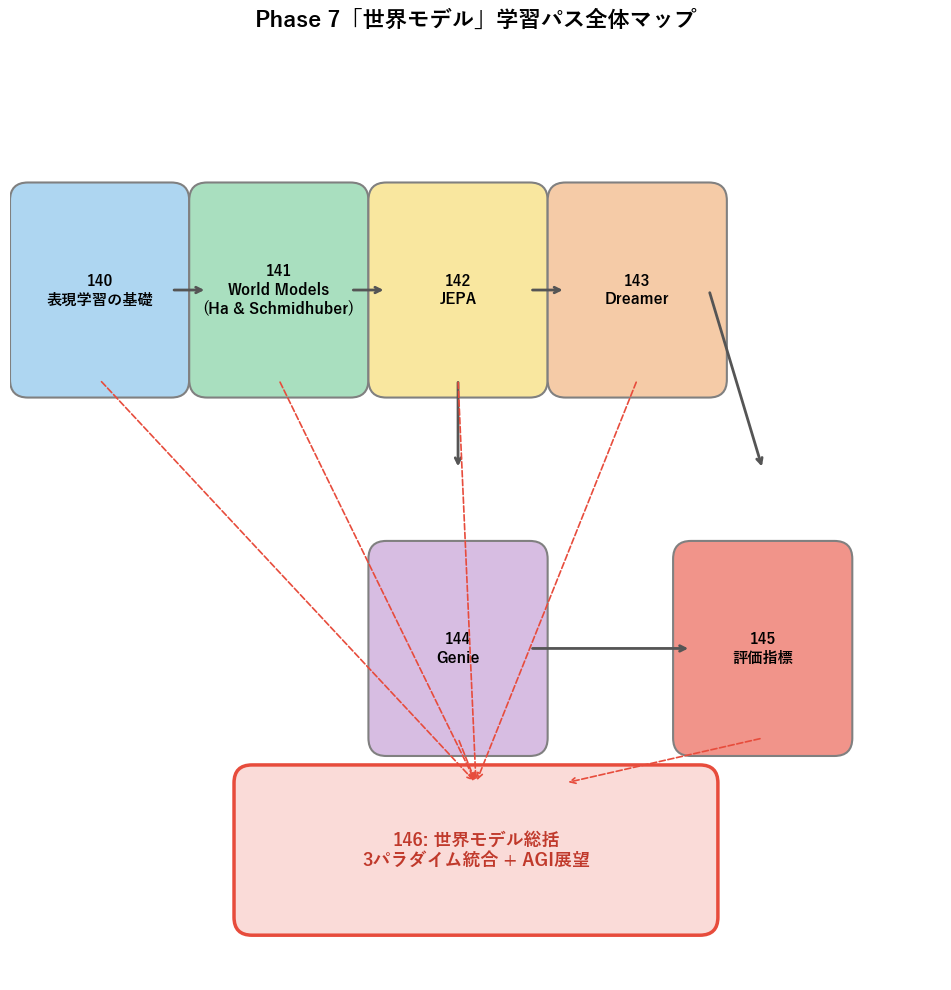

In [2]:
# ============================================================
# Phase 7 学習パスの全体マップ
# ============================================================

def visualize_phase7_learning_path():
    """Phase 7の学習パスとノートブック間の関係を可視化"""
    fig, ax = plt.subplots(figsize=(18, 10))

    # ノートブック情報: (label, x, y, color)
    notebooks = [
        ('140\n表現学習の基礎',     0.08, 0.75, '#AED6F1'),
        ('141\nWorld Models\n(Ha & Schmidhuber)', 0.28, 0.75, '#A9DFBF'),
        ('142\nJEPA',              0.48, 0.75, '#F9E79F'),
        ('143\nDreamer',           0.68, 0.75, '#F5CBA7'),
        ('144\nGenie',             0.48, 0.35, '#D7BDE2'),
        ('145\n評価指標',           0.82, 0.35, '#F1948A'),
    ]

    for label, x, y, color in notebooks:
        box = FancyBboxPatch((x - 0.08, y - 0.10), 0.16, 0.20,
                             boxstyle='round,pad=0.02',
                             facecolor=color, edgecolor='gray', linewidth=1.5)
        ax.add_patch(box)
        ax.text(x, y, label, ha='center', va='center',
                fontsize=11, fontweight='bold')

    # 矢印: 学習の流れ
    arrows = [
        (0.16, 0.75, 0.20, 0.75),   # 140 -> 141
        (0.36, 0.75, 0.40, 0.75),   # 141 -> 142
        (0.56, 0.75, 0.60, 0.75),   # 142 -> 143
        (0.48, 0.65, 0.48, 0.55),   # 142 -> 144
        (0.56, 0.35, 0.74, 0.35),   # 144 -> 145
        (0.76, 0.75, 0.82, 0.55),   # 143 -> 145
    ]

    for x1, y1, x2, y2 in arrows:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2.0,
                                   color='#555555'))

    # 統括ボックス
    synth_box = FancyBboxPatch((0.25, 0.05), 0.50, 0.15,
                               boxstyle='round,pad=0.02',
                               facecolor='#FADBD8', edgecolor='#E74C3C',
                               linewidth=2.5)
    ax.add_patch(synth_box)
    ax.text(0.50, 0.125, '146: 世界モデル総括\n3パラダイム統合 + AGI展望',
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='#C0392B')

    # 統括への矢印
    for x_src in [0.08, 0.28, 0.48, 0.68]:
        ax.annotate('', xy=(0.50, 0.20), xytext=(x_src, 0.65),
                    arrowprops=dict(arrowstyle='->', lw=1.2,
                                   color='#E74C3C', linestyle='dashed'))
    ax.annotate('', xy=(0.50, 0.20), xytext=(0.48, 0.25),
                arrowprops=dict(arrowstyle='->', lw=1.2,
                               color='#E74C3C', linestyle='dashed'))
    ax.annotate('', xy=(0.60, 0.20), xytext=(0.82, 0.25),
                arrowprops=dict(arrowstyle='->', lw=1.2,
                               color='#E74C3C', linestyle='dashed'))

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Phase 7「世界モデル」学習パス全体マップ',
                 fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

visualize_phase7_learning_path()

### 各ノートブックの核心コンセプト

#### Notebook 140: 予測のための表現学習

Phase 7 全体の**土台**となる章です。ピクセル空間予測の限界を実験的に示し、
対照学習（InfoNCE）による表現空間の構築を行いました。

- **ピクセル空間の問題点**: 高次元・ノイズに弱い・意味的距離と乖離
- **対照学習**: 正例ペアを近づけ、負例ペアを遠ざける
- **線形プローブ**: エンコーダの質を定量的に評価

**重要な洞察**: 良い表現を学習すれば、予測はピクセル空間ではなく特徴空間で行うべき

---

#### Notebook 141: Ha & Schmidhuber の World Models

世界モデルの**原型**を学ぶ章です。VAE でフレームをエンコードし、
MDN-RNN で潜在空間の時系列を予測する古典的アプローチを実装しました。

- **VAE**: 観測を潜在表現 z に圧縮
- **MDN-RNN**: z の時系列を混合ガウスで予測
- **Controller**: 潜在空間上で行動を決定
- **「夢」の中での訓練**: 世界モデル内でのシミュレーション

---

#### Notebook 142: JEPA (Joint Embedding Predictive Architecture)

LeCun が提唱する**次世代パラダイム**です。ピクセル復元を行わず、
潜在空間で直接未来の表現を予測します。

- **コラプス防止**: EMA ターゲットエンコーダ + 非対称構造
- **エネルギーベースの解釈**: 互換状態のエネルギーが低くなるよう学習
- **生成モデルとの違い**: 全てのピクセル詳細を予測しない = 効率的

---

#### Notebook 143: Dreamer（潜在空間での想像と計画）

世界モデルを**強化学習に直接適用**する手法です。RSSM を用いて
エージェントが「想像」の中で方策を改善します。

- **RSSM**: 決定論的 + 確率的な状態遷移モデル
- **想像パス**: 世界モデル内で行動のシーケンスをシミュレート
- **Actor-Critic**: 想像上の報酬で方策を最適化

---

#### Notebook 144: Genie（潜在行動空間の発見）

**行動ラベルなし**で動画から世界モデルを学習する革新的手法です。

- **VQ-VAE**: 離散的な潜在行動コードブック
- **潜在行動推定**: 連続フレーム間の差分から行動を推定
- **インタラクティブ環境生成**: 学習した世界モデルで新しい環境を生成

---

#### Notebook 145: 世界モデルの評価指標

世界モデルの品質を**定量的に測定**する手法を整理しました。

- **FVD (Frechet Video Distance)**: 動画の分布間距離
- **LPIPS**: 知覚的な画像類似度
- **ATC (Action-conditioned Temporal Consistency)**: 行動条件付き時間的整合性
- **下流タスク評価**: 世界モデル上の強化学習性能

---

<a id="section3"></a>
## 3. 3つのパラダイム比較: ピクセル / 特徴 / 潜在行動

Phase 7 で学んだ世界モデルは、**予測を行う空間** によって大きく3つのパラダイムに分類できます。

| 項目 | ピクセル空間予測 | 特徴空間予測 (JEPA) | 潜在行動空間 (Genie) |
|------|------------------|---------------------|----------------------|
| **代表モデル** | Ha & Schmidhuber (141) | JEPA (142), Dreamer (143) | Genie (144) |
| **予測対象** | 次フレームのピクセル/潜在変数 | 次状態の潜在表現 | 次フレーム + 潜在行動 |
| **教師信号** | 再構成誤差 (MSE, VAE ELBO) | 埋め込み間距離 | VQ コードブック + 再構成 |
| **行動の扱い** | 明示的入力 | 条件付き/なし | 動画から自動推定 |
| **コラプス対策** | 再構成ロス自体が防止 | EMA, 非対称構造 | 離散化(VQ) |
| **強み** | 直感的・可視化容易 | 効率的・抽象的 | 行動ラベル不要 |
| **弱み** | 計算コスト大・ノイズに弱い | 生成不可（直接的に） | 離散化の情報損失 |
| **関連NB** | 140, 141 | 140, 142, 143 | 140, 144 |

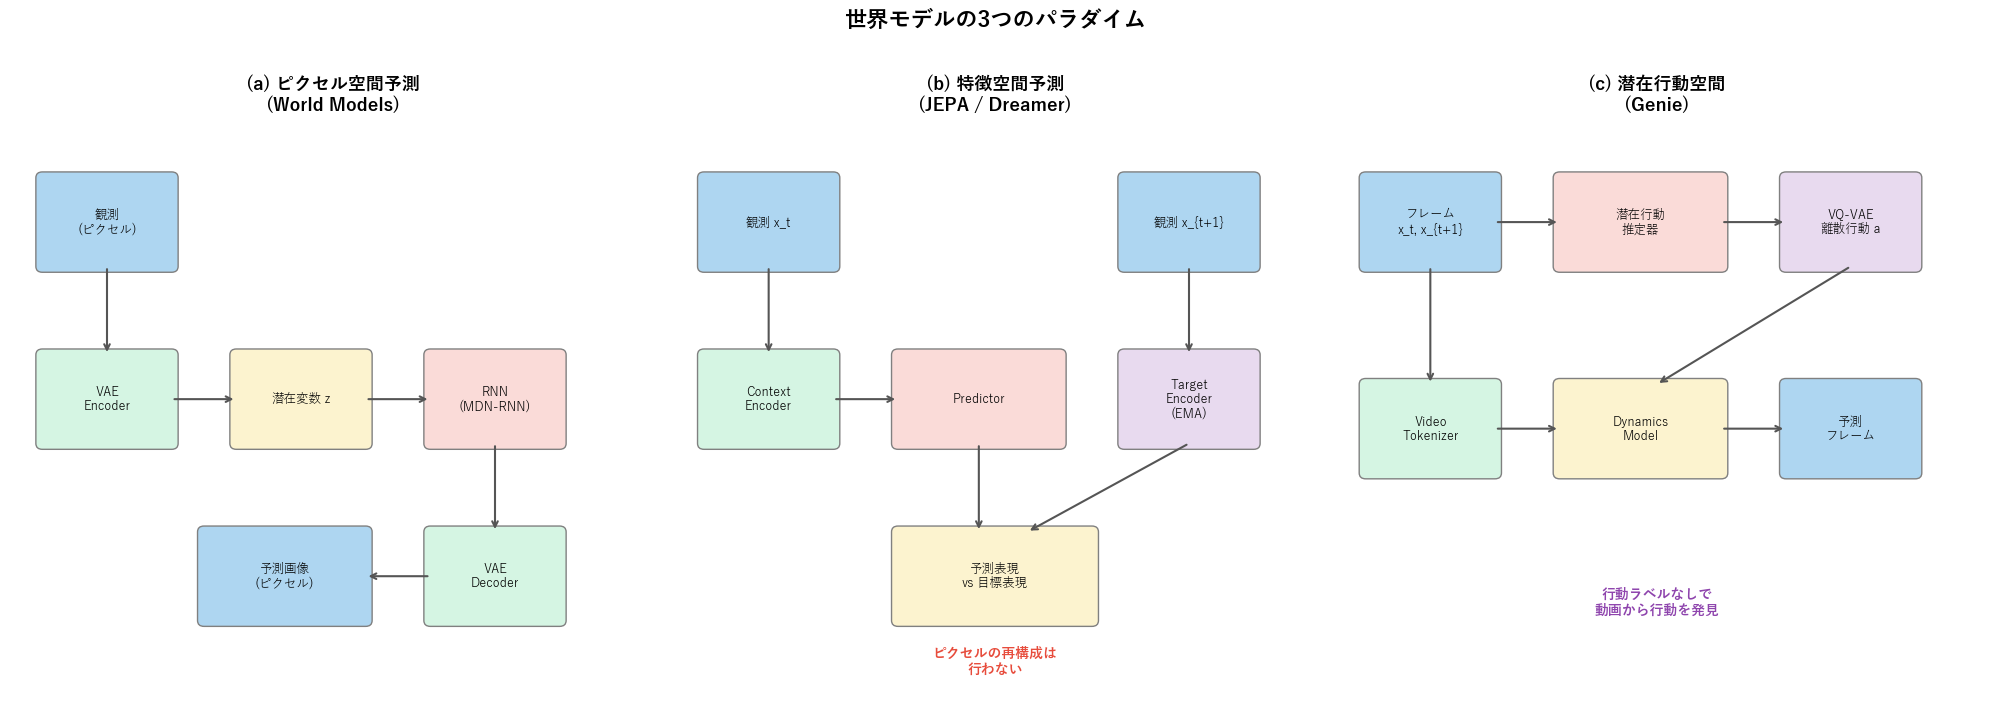

In [3]:
# ============================================================
# 3パラダイムの概念図
# ============================================================

def plot_three_paradigms():
    """3つの予測パラダイムを視覚的に比較する"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # --- パラダイム 1: ピクセル空間予測 ---
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title('(a) ピクセル空間予測\n(World Models)', fontsize=13,
                 fontweight='bold')

    # 観測 -> VAE Encoder -> z -> RNN -> z' -> VAE Decoder -> 予測画像
    boxes_a = [
        (0.5, 7.5, 2.0, 1.5, '観測\n(ピクセル)', '#AED6F1'),
        (0.5, 4.5, 2.0, 1.5, 'VAE\nEncoder', '#D5F5E3'),
        (3.5, 4.5, 2.0, 1.5, '潜在変数 z', '#FCF3CF'),
        (6.5, 4.5, 2.0, 1.5, 'RNN\n(MDN-RNN)', '#FADBD8'),
        (6.5, 1.5, 2.0, 1.5, 'VAE\nDecoder', '#D5F5E3'),
        (3.0, 1.5, 2.5, 1.5, '予測画像\n(ピクセル)', '#AED6F1'),
    ]
    for bx, by, bw, bh, txt, col in boxes_a:
        rect = FancyBboxPatch((bx, by), bw, bh,
                              boxstyle='round,pad=0.1',
                              facecolor=col, edgecolor='gray')
        ax.add_patch(rect)
        ax.text(bx + bw / 2, by + bh / 2, txt,
                ha='center', va='center', fontsize=9)

    arrows_a = [
        (1.5, 7.5, 1.5, 6.0),
        (2.5, 5.25, 3.5, 5.25),
        (5.5, 5.25, 6.5, 5.25),
        (7.5, 4.5, 7.5, 3.0),
        (6.5, 2.25, 5.5, 2.25),
    ]
    for x1, y1, x2, y2 in arrows_a:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))
    ax.axis('off')

    # --- パラダイム 2: 特徴空間予測 (JEPA) ---
    ax = axes[1]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title('(b) 特徴空間予測\n(JEPA / Dreamer)', fontsize=13,
                 fontweight='bold')

    boxes_b = [
        (0.5, 7.5, 2.0, 1.5, '観測 x_t', '#AED6F1'),
        (0.5, 4.5, 2.0, 1.5, 'Context\nEncoder', '#D5F5E3'),
        (3.5, 4.5, 2.5, 1.5, 'Predictor', '#FADBD8'),
        (7.0, 7.5, 2.0, 1.5, '観測 x_{t+1}', '#AED6F1'),
        (7.0, 4.5, 2.0, 1.5, 'Target\nEncoder\n(EMA)', '#E8DAEF'),
        (3.5, 1.5, 3.0, 1.5, '予測表現\nvs 目標表現', '#FCF3CF'),
    ]
    for bx, by, bw, bh, txt, col in boxes_b:
        rect = FancyBboxPatch((bx, by), bw, bh,
                              boxstyle='round,pad=0.1',
                              facecolor=col, edgecolor='gray')
        ax.add_patch(rect)
        ax.text(bx + bw / 2, by + bh / 2, txt,
                ha='center', va='center', fontsize=9)

    arrows_b = [
        (1.5, 7.5, 1.5, 6.0),
        (2.5, 5.25, 3.5, 5.25),
        (8.0, 7.5, 8.0, 6.0),
        (4.75, 4.5, 4.75, 3.0),
        (8.0, 4.5, 5.5, 3.0),
    ]
    for x1, y1, x2, y2 in arrows_b:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))

    ax.text(5.0, 0.8, 'ピクセルの再構成は\n行わない',
            ha='center', va='center', fontsize=10, color='#E74C3C',
            fontweight='bold', style='italic')
    ax.axis('off')

    # --- パラダイム 3: 潜在行動空間 (Genie) ---
    ax = axes[2]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title('(c) 潜在行動空間\n(Genie)', fontsize=13,
                 fontweight='bold')

    boxes_c = [
        (0.5, 7.5, 2.0, 1.5, 'フレーム\nx_t, x_{t+1}', '#AED6F1'),
        (3.5, 7.5, 2.5, 1.5, '潜在行動\n推定器', '#FADBD8'),
        (7.0, 7.5, 2.0, 1.5, 'VQ-VAE\n離散行動 a', '#E8DAEF'),
        (0.5, 4.0, 2.0, 1.5, 'Video\nTokenizer', '#D5F5E3'),
        (3.5, 4.0, 2.5, 1.5, 'Dynamics\nModel', '#FCF3CF'),
        (7.0, 4.0, 2.0, 1.5, '予測\nフレーム', '#AED6F1'),
    ]
    for bx, by, bw, bh, txt, col in boxes_c:
        rect = FancyBboxPatch((bx, by), bw, bh,
                              boxstyle='round,pad=0.1',
                              facecolor=col, edgecolor='gray')
        ax.add_patch(rect)
        ax.text(bx + bw / 2, by + bh / 2, txt,
                ha='center', va='center', fontsize=9)

    arrows_c = [
        (2.5, 8.25, 3.5, 8.25),
        (6.0, 8.25, 7.0, 8.25),
        (1.5, 7.5, 1.5, 5.5),
        (2.5, 4.75, 3.5, 4.75),
        (8.0, 7.5, 5.0, 5.5),
        (6.0, 4.75, 7.0, 4.75),
    ]
    for x1, y1, x2, y2 in arrows_c:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))

    ax.text(5.0, 1.8, '行動ラベルなしで\n動画から行動を発見',
            ha='center', va='center', fontsize=10, color='#8E44AD',
            fontweight='bold', style='italic')
    ax.axis('off')

    plt.suptitle('世界モデルの3つのパラダイム', fontsize=16,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_three_paradigms()

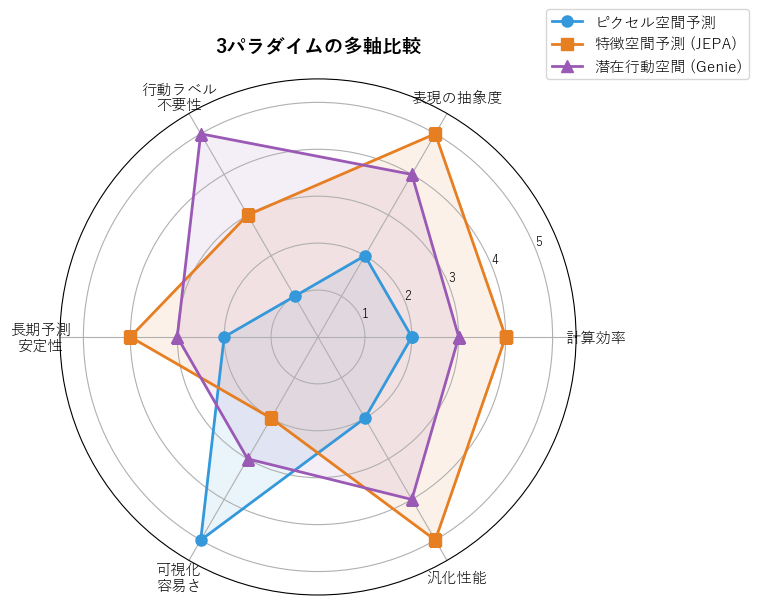

In [4]:
# ============================================================
# 3パラダイムのレーダーチャート比較
# ============================================================

def plot_paradigm_radar():
    """3パラダイムを多軸レーダーチャートで比較"""
    categories = [
        '計算効率', '表現の抽象度', '行動ラベル\n不要性',
        '長期予測\n安定性', '可視化\n容易さ', '汎化性能',
    ]
    N = len(categories)

    # 各パラダイムのスコア (1-5)
    pixel_scores  = [2, 2, 1, 2, 5, 2]
    jepa_scores   = [4, 5, 3, 4, 2, 5]
    genie_scores  = [3, 4, 5, 3, 3, 4]

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # 閉じるために先頭を追加

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for scores, label, color, marker in [
        (pixel_scores, 'ピクセル空間予測', '#3498DB', 'o'),
        (jepa_scores, '特徴空間予測 (JEPA)', '#E67E22', 's'),
        (genie_scores, '潜在行動空間 (Genie)', '#9B59B6', '^'),
    ]:
        values = scores + scores[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=label,
                color=color, marker=marker, markersize=8)
        ax.fill(angles, values, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=9)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
    ax.set_title('3パラダイムの多軸比較', fontsize=14,
                 fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

plot_paradigm_radar()

### どのパラダイムを選ぶべきか？

実際のプロジェクトで世界モデルを構築する際、パラダイムの選択は
**タスクの要件**によって決まります：

| 要件 | 推奨パラダイム | 理由 |
|------|---------------|------|
| 予測結果を人間が確認したい | ピクセル空間予測 | 生成画像を直接検証可能 |
| 計算リソースが限られている | 特徴空間予測 (JEPA) | ピクセル再構成が不要で効率的 |
| 行動ラベルが入手困難 | 潜在行動空間 (Genie) | 教師なしで行動を発見 |
| 強化学習エージェントの訓練 | Dreamer (ハイブリッド) | 想像パスで効率的に方策改善 |
| 大規模動画データの活用 | Genie / JEPA | インターネット規模のデータに対応 |

### パラダイム間の相互関係

3つのパラダイムは完全に独立ではなく、相互に影響し合っています：

1. **ピクセル空間 → 特徴空間**: Notebook 140 で示したように、ピクセル空間の限界が特徴空間予測の動機となった
2. **特徴空間 → 潜在行動空間**: JEPA の「ピクセルを生成しない」思想が、Genie の潜在行動推定にも通じる
3. **Dreamer = ピクセル空間 + 特徴空間のハイブリッド**: RSSM は潜在空間で予測しつつ、画像デコーダも持つ

**最近の研究トレンド**: 3パラダイムの**統合**が進んでおり、特徴空間予測をベースにしつつ、
必要に応じてピクセル空間へのデコードも可能な柔軟なアーキテクチャが増えています。

---

<a id="section4"></a>
## 4. アーキテクチャ比較チャート

Phase 7 で扱った全モデルのアーキテクチャを、以下の軸で比較します：

| モデル | エンコーダ | 遷移モデル | デコーダ | 行動 | コラプス対策 | NB |
|--------|-----------|-----------|---------|------|-------------|----|
| **World Models** | VAE (CNN) | MDN-RNN | VAE (CNN) | 明示的 | 再構成ロス | 141 |
| **JEPA** | ViT | Predictor MLP/Transformer | なし | 条件付き/なし | EMA Target | 142 |
| **DreamerV3** | CNN/ViT | RSSM (GRU+離散) | CNN | 明示的 | KLバランシング | 143 |
| **Genie** | Video Tokenizer | ST-Transformer | Token Decoder | VQ推定 | VQ離散化 | 144 |

### 共通構造の発見

全てのモデルに共通する **3つのコンポーネント** があります：

1. **エンコーダ**: 観測を何らかの潜在表現に変換
2. **遷移モデル (Dynamics Model)**: 潜在空間で次の状態を予測
3. **何らかの学習信号**: 再構成、対比、VQコミットメントロス

違いは「**どの空間で予測し、どの空間に結果を返すか**」です。

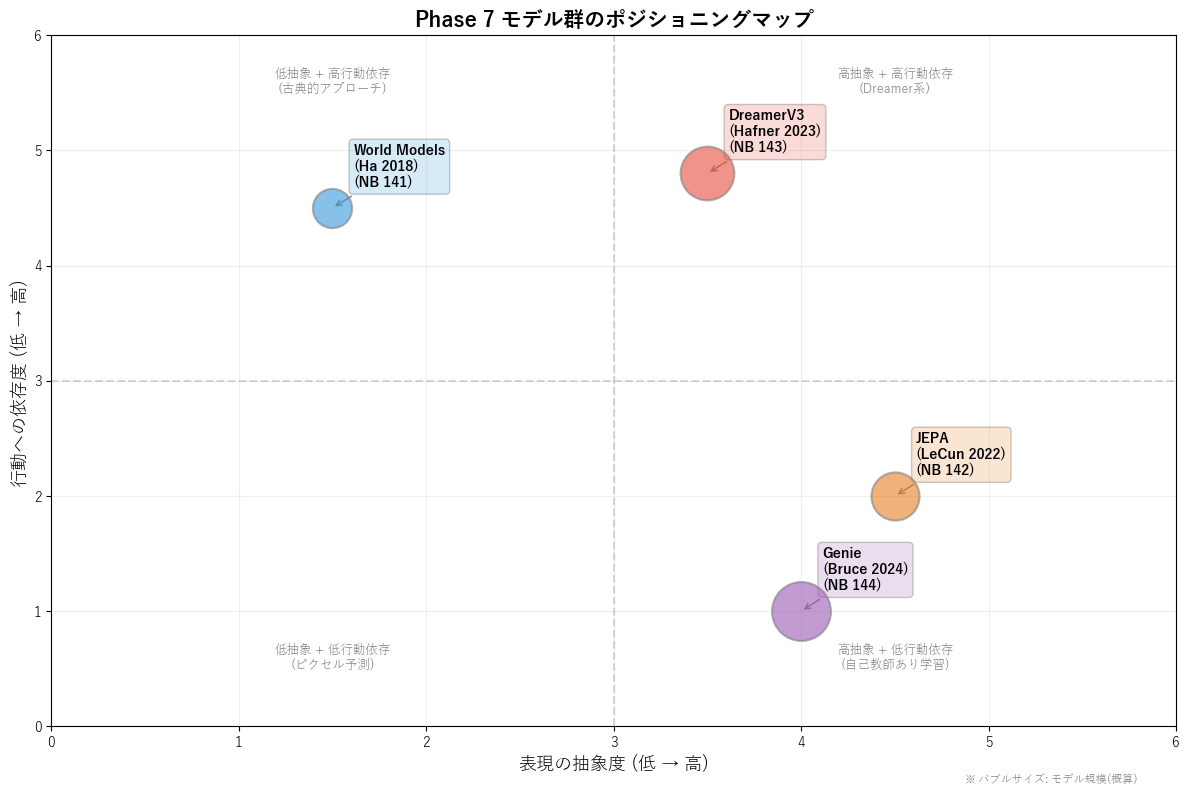

In [5]:
# ============================================================
# アーキテクチャ比較: パラメータ規模 vs 学習信号の種類
# ============================================================

def plot_architecture_comparison():
    """各モデルのアーキテクチャ特性を2次元で比較"""
    fig, ax = plt.subplots(figsize=(12, 8))

    # モデルデータ: (抽象度, 行動依存度, バブルサイズ, 名前, 色)
    models = [
        (1.5, 4.5, 800, 'World Models\n(Ha 2018)', '#3498DB', 'NB 141'),
        (4.5, 2.0, 1200, 'JEPA\n(LeCun 2022)', '#E67E22', 'NB 142'),
        (3.5, 4.8, 1500, 'DreamerV3\n(Hafner 2023)', '#E74C3C', 'NB 143'),
        (4.0, 1.0, 1800, 'Genie\n(Bruce 2024)', '#9B59B6', 'NB 144'),
    ]

    for abstraction, action_dep, size, name, color, nb in models:
        ax.scatter(abstraction, action_dep, s=size, c=color,
                   alpha=0.6, edgecolors='gray', linewidth=1.5, zorder=5)
        ax.annotate(f'{name}\n({nb})',
                    xy=(abstraction, action_dep),
                    xytext=(15, 15), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray'),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                              alpha=0.2))

    ax.set_xlabel('表現の抽象度 (低 → 高)', fontsize=13)
    ax.set_ylabel('行動への依存度 (低 → 高)', fontsize=13)
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.set_title('Phase 7 モデル群のポジショニングマップ',
                 fontsize=15, fontweight='bold')
    ax.axhline(y=3, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=3, color='gray', linestyle='--', alpha=0.3)

    # 象限ラベル
    ax.text(1.5, 5.5, '低抽象 + 高行動依存\n(古典的アプローチ)',
            ha='center', fontsize=9, color='gray', style='italic')
    ax.text(4.5, 5.5, '高抽象 + 高行動依存\n(Dreamer系)',
            ha='center', fontsize=9, color='gray', style='italic')
    ax.text(1.5, 0.5, '低抽象 + 低行動依存\n(ピクセル予測)',
            ha='center', fontsize=9, color='gray', style='italic')
    ax.text(4.5, 0.5, '高抽象 + 低行動依存\n(自己教師あり学習)',
            ha='center', fontsize=9, color='gray', style='italic')

    ax.text(5.8, -0.5, '※ バブルサイズ: モデル規模(概算)',
            ha='right', fontsize=8, color='gray')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_architecture_comparison()

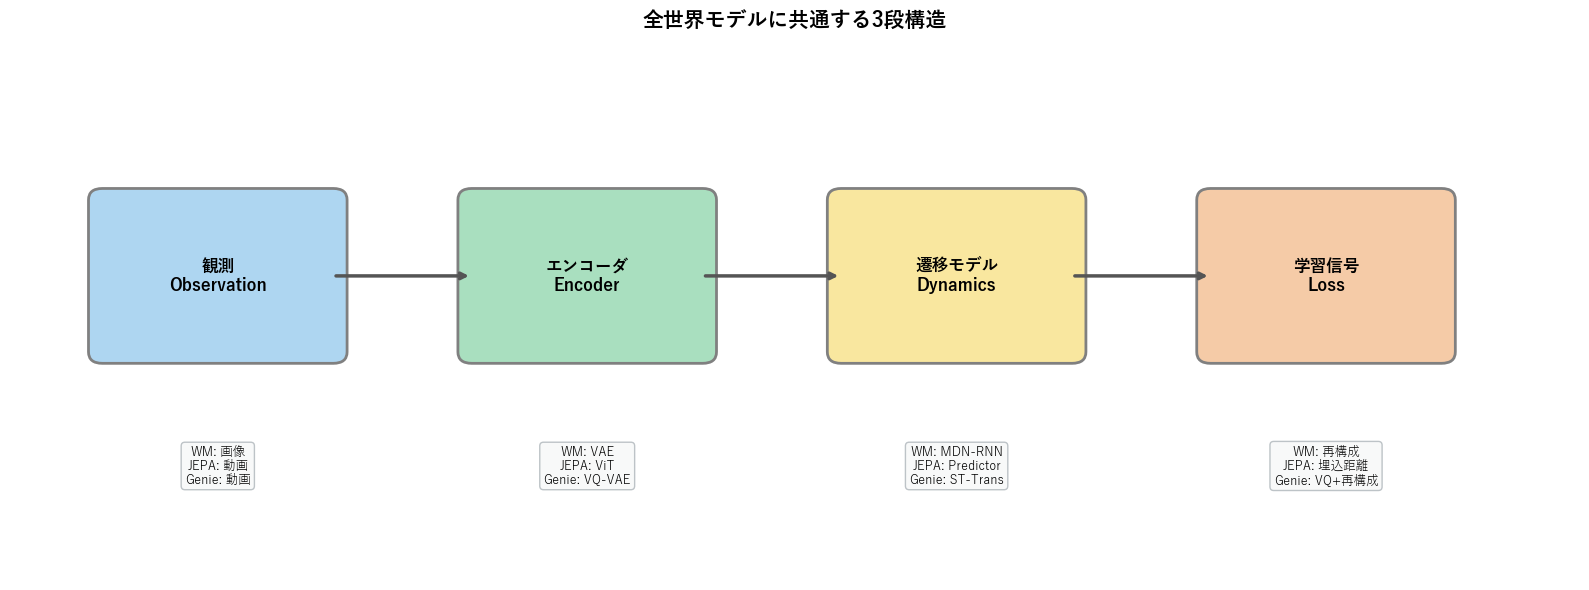

In [6]:
# ============================================================
# 共通構造の図解: Encoder → Dynamics → Signal
# ============================================================

def plot_common_structure():
    """全世界モデルに共通する3段構造を図解"""
    fig, ax = plt.subplots(figsize=(16, 6))

    # 共通フレームワーク
    stages = [
        (1.0, 3.0, 2.5, 2.0, '観測\nObservation', '#AED6F1'),
        (5.0, 3.0, 2.5, 2.0, 'エンコーダ\nEncoder', '#A9DFBF'),
        (9.0, 3.0, 2.5, 2.0, '遷移モデル\nDynamics', '#F9E79F'),
        (13.0, 3.0, 2.5, 2.0, '学習信号\nLoss', '#F5CBA7'),
    ]

    for x, y, w, h, txt, col in stages:
        rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                              facecolor=col, edgecolor='gray', linewidth=2)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, txt,
                ha='center', va='center', fontsize=12, fontweight='bold')

    for x_start in [3.5, 7.5, 11.5]:
        ax.annotate('', xy=(x_start + 1.5, 4.0),
                    xytext=(x_start, 4.0),
                    arrowprops=dict(arrowstyle='->', lw=2.5, color='#555'))

    # 各モデルの具体例を下段に配置
    details = [
        (2.25, 1.5, 'WM: 画像\nJEPA: 動画\nGenie: 動画'),
        (6.25, 1.5, 'WM: VAE\nJEPA: ViT\nGenie: VQ-VAE'),
        (10.25, 1.5, 'WM: MDN-RNN\nJEPA: Predictor\nGenie: ST-Trans'),
        (14.25, 1.5, 'WM: 再構成\nJEPA: 埋込距離\nGenie: VQ+再構成'),
    ]

    for x, y, txt in details:
        ax.text(x, y, txt, ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F8F9F9',
                          edgecolor='#BDC3C7'),
                )

    ax.set_xlim(0, 17)
    ax.set_ylim(0, 7)
    ax.axis('off')
    ax.set_title('全世界モデルに共通する3段構造',
                 fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

plot_common_structure()

### 技術の進化軸

Phase 7 の各モデルは、以下の**進化の方向性**を示しています：

| 進化軸 | 初期 (NB 141) | 中間 (NB 142-143) | 最新 (NB 144) |
|--------|---------------|-------------------|---------------|
| **エンコーダ** | CNN (VAE) | ViT / CNN | Video Tokenizer (VQ) |
| **遷移モデル** | RNN (LSTM/GRU) | Transformer / GRU | Spatiotemporal Transformer |
| **行動表現** | 環境から与えられる | エージェントが選ぶ | 動画から自動発見 |
| **訓練データ** | RL環境のロールアウト | ラベルなし動画 | インターネット動画 |
| **スケール** | 小規模 (64x64) | 中規模 | 大規模 (11B params) |

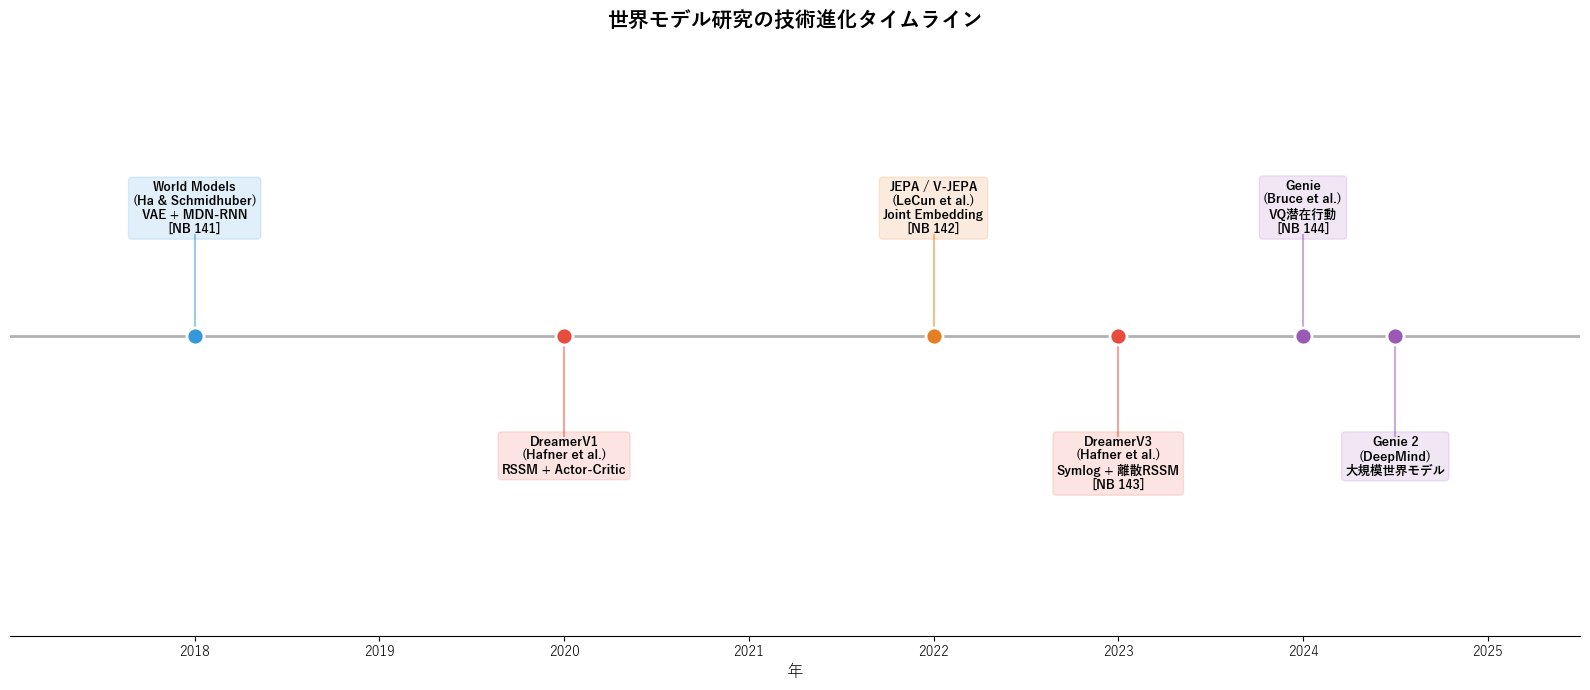

In [7]:
# ============================================================
# 技術進化のタイムライン
# ============================================================

def plot_evolution_timeline():
    """世界モデルの技術進化タイムラインを描画"""
    fig, ax = plt.subplots(figsize=(16, 7))

    # タイムライン上のモデル
    events = [
        (2018, 0.7, 'World Models\n(Ha & Schmidhuber)',
         '#3498DB', 'VAE + MDN-RNN', 'NB 141'),
        (2020, 0.3, 'DreamerV1\n(Hafner et al.)',
         '#E74C3C', 'RSSM + Actor-Critic', '-'),
        (2022, 0.7, 'JEPA / V-JEPA\n(LeCun et al.)',
         '#E67E22', 'Joint Embedding', 'NB 142'),
        (2023, 0.3, 'DreamerV3\n(Hafner et al.)',
         '#E74C3C', 'Symlog + 離散RSSM', 'NB 143'),
        (2024, 0.7, 'Genie\n(Bruce et al.)',
         '#9B59B6', 'VQ潜在行動', 'NB 144'),
        (2024.5, 0.3, 'Genie 2\n(DeepMind)',
         '#9B59B6', '大規模世界モデル', '-'),
    ]

    # ベースライン
    ax.plot([2017, 2025.5], [0.5, 0.5], 'k-', linewidth=2, alpha=0.3)

    for year, y_pos, name, color, tech, nb in events:
        ax.scatter(year, 0.5, s=150, c=color, zorder=5,
                   edgecolors='white', linewidth=2)
        ax.plot([year, year], [0.5, y_pos], '-', color=color,
                linewidth=1.5, alpha=0.5)

        label = f'{name}\n{tech}'
        if nb != '-':
            label += f'\n[{nb}]'

        ax.text(year, y_pos, label, ha='center',
                va='bottom' if y_pos > 0.5 else 'top',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          alpha=0.15, edgecolor=color))

    ax.set_xlim(2017, 2025.5)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('年', fontsize=12)
    ax.set_xticks(range(2018, 2026))
    ax.set_yticks([])
    ax.set_title('世界モデル研究の技術進化タイムライン',
                 fontsize=15, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_evolution_timeline()

---

<a id="section5"></a>
## 5. 全カリキュラム統合マップ (Phase 1-7)

Phase 7「世界モデル」は、Phase 1-6 で積み上げた全技術の**集大成**です。
以下に、全 Phase の位置づけと Phase 7 への接続を整理します。

| Phase | テーマ | Notebook | Phase 7 への接続 |
|-------|--------|----------|------------------|
| **1** | ニューラルネットワーク基礎 | 1-20 | 全モデルの基盤（活性化関数、損失関数、最適化） |
| **2** | CNN / 画像認識 | 21-50 | エンコーダ/デコーダの畳み込み層 |
| **3** | 系列モデリング | 51-70 | RNN/LSTM/GRU → World Models の MDN-RNN |
| **4** | Attention / Transformer | 71-100 | Self-Attention → JEPA, Genie の Transformer |
| **5** | 生成モデル | 101-120 | VAE → World Models のエンコーダ、VQ-VAE → Genie |
| **6** | 時空間モデリング | 121-139 | 動画理解 → 世界モデルの入出力形式 |
| **7** | **世界モデル** | **140-146** | **統合: 全技術の上に成り立つ** |

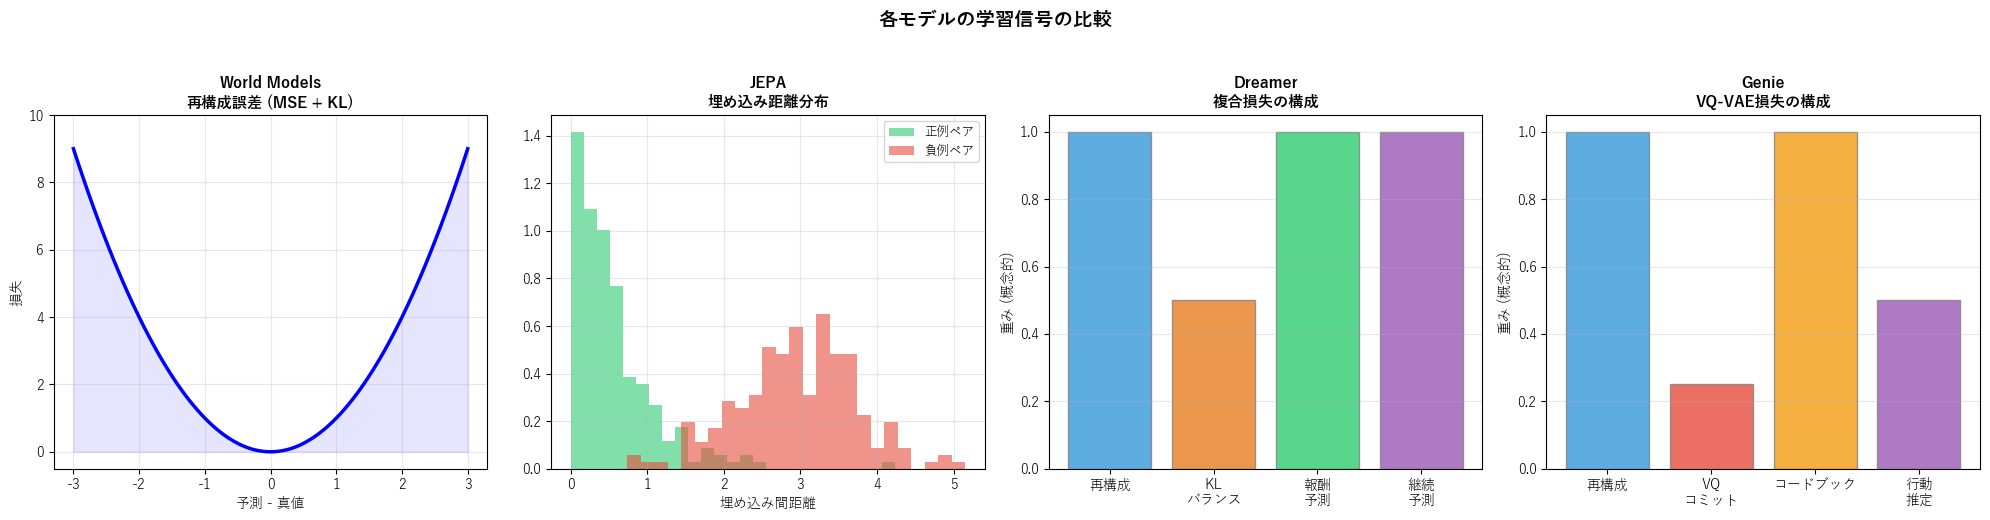

In [8]:
# ============================================================
# 学習信号（損失関数）の比較
# ============================================================

def plot_loss_comparison():
    """各モデルの損失関数を概念的に比較"""
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # World Models: 再構成誤差
    ax = axes[0]
    x = np.linspace(-3, 3, 100)
    y_mse = x ** 2
    ax.plot(x, y_mse, 'b-', linewidth=2.5)
    ax.fill_between(x, y_mse, alpha=0.1, color='blue')
    ax.set_title('World Models\n再構成誤差 (MSE + KL)', fontsize=11,
                 fontweight='bold')
    ax.set_xlabel('予測 - 真値', fontsize=10)
    ax.set_ylabel('損失', fontsize=10)
    ax.set_ylim(-0.5, 10)
    ax.grid(True, alpha=0.3)

    # JEPA: 埋め込み距離
    ax = axes[1]
    pos_dist = np.random.exponential(0.5, 200)
    neg_dist = np.random.normal(3.0, 0.8, 200)
    neg_dist = neg_dist[neg_dist > 0]
    ax.hist(pos_dist, bins=25, alpha=0.6, color='#2ECC71',
            label='正例ペア', density=True)
    ax.hist(neg_dist, bins=25, alpha=0.6, color='#E74C3C',
            label='負例ペア', density=True)
    ax.set_title('JEPA\n埋め込み距離分布', fontsize=11,
                 fontweight='bold')
    ax.set_xlabel('埋め込み間距離', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Dreamer: 複合損失
    ax = axes[2]
    components = ['再構成', 'KL\nバランス', '報酬\n予測', '継続\n予測']
    weights = [1.0, 0.5, 1.0, 1.0]
    colors = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']
    ax.bar(components, weights, color=colors, alpha=0.8,
           edgecolor='gray')
    ax.set_title('Dreamer\n複合損失の構成', fontsize=11,
                 fontweight='bold')
    ax.set_ylabel('重み (概念的)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Genie: VQ損失
    ax = axes[3]
    components_g = ['再構成', 'VQ\nコミット', 'コードブック', '行動\n推定']
    weights_g = [1.0, 0.25, 1.0, 0.5]
    colors_g = ['#3498DB', '#E74C3C', '#F39C12', '#9B59B6']
    ax.bar(components_g, weights_g, color=colors_g, alpha=0.8,
           edgecolor='gray')
    ax.set_title('Genie\nVQ-VAE損失の構成', fontsize=11,
                 fontweight='bold')
    ax.set_ylabel('重み (概念的)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('各モデルの学習信号の比較', fontsize=14,
                 fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

plot_loss_comparison()

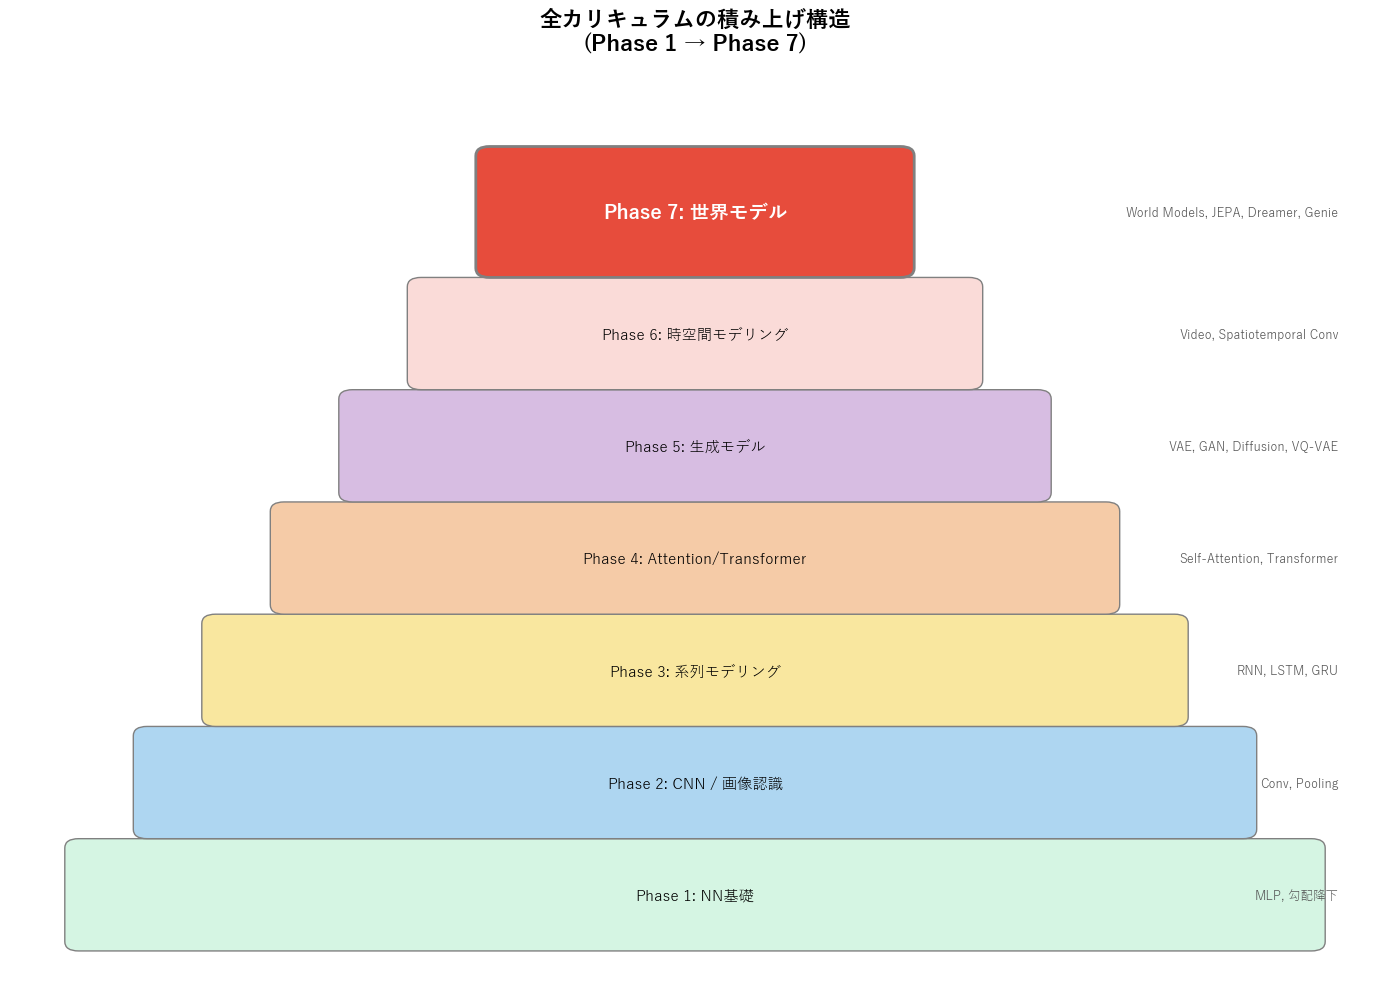

In [9]:
# ============================================================
# Phase 1-7 の積み上げ構造を可視化
# ============================================================

def plot_curriculum_pyramid():
    """全カリキュラムをピラミッド型で可視化"""
    fig, ax = plt.subplots(figsize=(14, 10))

    phases = [
        (1, 'Phase 1: NN基礎',           '#D5F5E3', 0.05, 0.02, 0.90, 0.10),
        (2, 'Phase 2: CNN / 画像認識',    '#AED6F1', 0.10, 0.14, 0.80, 0.10),
        (3, 'Phase 3: 系列モデリング',     '#F9E79F', 0.15, 0.26, 0.70, 0.10),
        (4, 'Phase 4: Attention/Transformer', '#F5CBA7', 0.20, 0.38, 0.60, 0.10),
        (5, 'Phase 5: 生成モデル',         '#D7BDE2', 0.25, 0.50, 0.50, 0.10),
        (6, 'Phase 6: 時空間モデリング',    '#FADBD8', 0.30, 0.62, 0.40, 0.10),
        (7, 'Phase 7: 世界モデル',         '#E74C3C', 0.35, 0.74, 0.30, 0.12),
    ]

    for phase_num, label, color, x, y, w, h in phases:
        rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.01',
                              facecolor=color, edgecolor='gray',
                              linewidth=2 if phase_num == 7 else 1)
        ax.add_patch(rect)
        fontsize = 14 if phase_num == 7 else 11
        weight = 'bold' if phase_num == 7 else 'normal'
        ax.text(x + w / 2, y + h / 2, label,
                ha='center', va='center', fontsize=fontsize,
                fontweight=weight,
                color='white' if phase_num == 7 else 'black')

    # 右側に接続情報
    connections = [
        (0.97, 0.07, 'MLP, 勾配降下'),
        (0.97, 0.19, 'Conv, Pooling'),
        (0.97, 0.31, 'RNN, LSTM, GRU'),
        (0.97, 0.43, 'Self-Attention, Transformer'),
        (0.97, 0.55, 'VAE, GAN, Diffusion, VQ-VAE'),
        (0.97, 0.67, 'Video, Spatiotemporal Conv'),
        (0.97, 0.80, 'World Models, JEPA, Dreamer, Genie'),
    ]

    for x, y, txt in connections:
        ax.text(x, y, txt, ha='right', va='center', fontsize=9,
                color='#555', style='italic')

    ax.set_xlim(0, 1.0)
    ax.set_ylim(-0.02, 0.95)
    ax.axis('off')
    ax.set_title('全カリキュラムの積み上げ構造\n(Phase 1 → Phase 7)',
                 fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

plot_curriculum_pyramid()

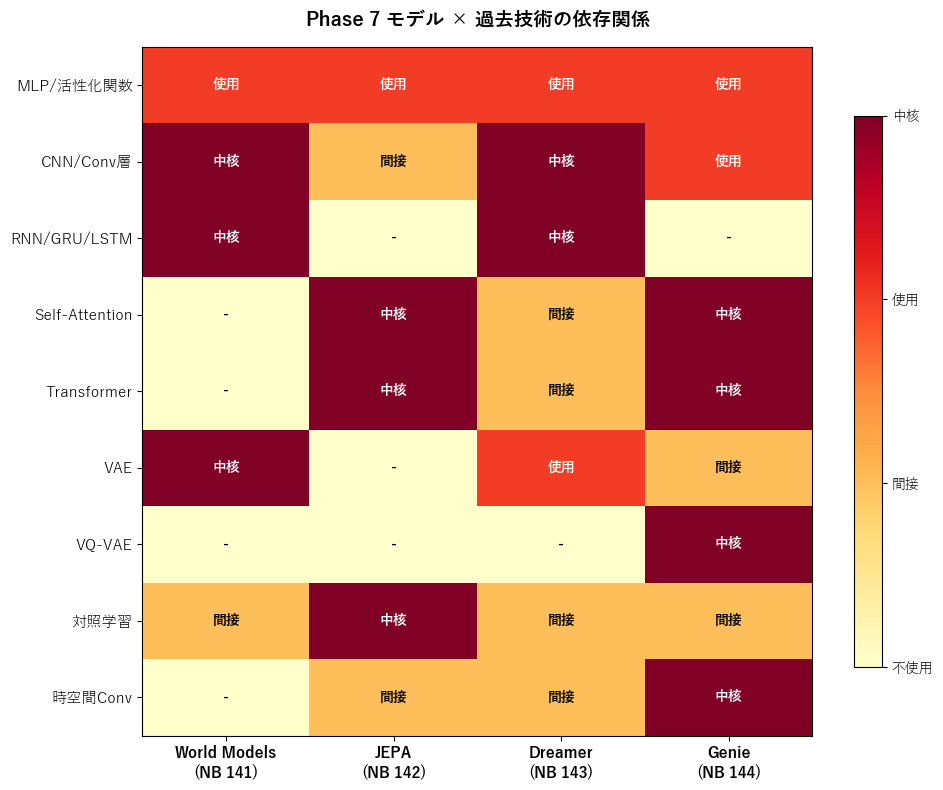

In [10]:
# ============================================================
# 技術の依存関係グラフ: Phase 7 の各モデルが使う過去の技術
# ============================================================

def plot_dependency_heatmap():
    """Phase 7の各モデルがどの過去技術に依存しているかをヒートマップで可視化"""
    models = ['World Models\n(NB 141)', 'JEPA\n(NB 142)',
              'Dreamer\n(NB 143)', 'Genie\n(NB 144)']
    technologies = [
        'MLP/活性化関数', 'CNN/Conv層', 'RNN/GRU/LSTM',
        'Self-Attention', 'Transformer', 'VAE',
        'VQ-VAE', '対照学習', '時空間Conv',
    ]

    # 依存度マトリックス (0: 不使用, 1: 間接, 2: 直接使用, 3: 中核技術)
    dependency = np.array([
        # WM   JEPA  Dreamer  Genie
        [2,    2,    2,       2],    # MLP
        [3,    1,    3,       2],    # CNN
        [3,    0,    3,       0],    # RNN/GRU
        [0,    3,    1,       3],    # Self-Attention
        [0,    3,    1,       3],    # Transformer
        [3,    0,    2,       1],    # VAE
        [0,    0,    0,       3],    # VQ-VAE
        [1,    3,    1,       1],    # 対照学習
        [0,    1,    1,       3],    # 時空間Conv
    ])

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.cm.YlOrRd
    im = ax.imshow(dependency, cmap=cmap, aspect='auto', vmin=0, vmax=3)

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=11, fontweight='bold')
    ax.set_yticks(range(len(technologies)))
    ax.set_yticklabels(technologies, fontsize=11)

    # 数値ラベル
    labels = {0: '-', 1: '間接', 2: '使用', 3: '中核'}
    for i in range(len(technologies)):
        for j in range(len(models)):
            val = dependency[i, j]
            color = 'white' if val >= 2 else 'black'
            ax.text(j, i, labels[val], ha='center', va='center',
                    fontsize=10, color=color, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels(['不使用', '間接', '使用', '中核'])

    ax.set_title('Phase 7 モデル × 過去技術の依存関係',
                 fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

plot_dependency_heatmap()

### カリキュラムを通じた核心的な学び

Phase 1-7 の全体を通じて、以下の **3つの大きな流れ** が見えてきます：

1. **表現の進化**: ピクセル → 特徴マップ → 潜在表現 → 埋め込み空間
   - Phase 2 の CNN 特徴から始まり、Phase 7 の JEPA 埋め込みに至る

2. **予測の進化**: 分類 → 系列予測 → 生成 → 世界モデル
   - Phase 1 のラベル予測から、Phase 7 の環境ダイナミクス予測へ

3. **学習信号の進化**: 教師あり → 自己教師あり → 環境との相互作用
   - Phase 1 の正解ラベルから、Phase 7 の探索と想像による学習へ

### 自習のための推奨リソース

Phase 7 で学んだ内容をさらに深めたい方への推奨リソースです。

#### 動画/講義

- **Yann LeCun の AAAI 2024 招待講演**: 世界モデルと JEPA の最新展望
- **Danijar Hafner の DreamerV3 解説**: 著者本人による技術解説
- **DeepMind の Genie ブログ記事**: Genie / Genie 2 の直感的な解説

#### コードベース

| リポジトリ | 内容 | 対応NB |
|-----------|------|--------|
| `worldmodels/ha-worldmodels` | World Models の公式実装 | 141 |
| `facebookresearch/jepa` | V-JEPA の公式実装 | 142 |
| `danijar/dreamerv3` | DreamerV3 の公式実装 | 143 |

#### 発展的な読み物

- Matsuo et al., "Deep Learning, Reinforcement Learning, and World Models" (2022)
- 松尾研究室「世界モデルと基盤モデル」技術報告
- NVIDIA Cosmos World Foundation Model テクニカルレポート (2024)

---

<a id="section6"></a>
## 6. AGI への接続と未来展望

### 世界モデルはなぜ AGI の鍵と言われるのか

Yann LeCun は 2022 年の論文 *"A Path Towards Autonomous Machine Intelligence"* で、
AGI（汎用人工知能）に必要な認知アーキテクチャを提案しました。その中核が **世界モデル** です。

#### LeCun の認知アーキテクチャ

| コンポーネント | 役割 | Phase 7 の対応 |
|---------------|------|---------------|
| **World Model** | 環境のダイナミクスを予測 | JEPA (NB 142), Dreamer (NB 143) |
| **Perception** | 観測を表現に変換 | 表現学習 (NB 140) |
| **Actor** | 行動を決定 | Dreamer の Actor (NB 143) |
| **Short-term Memory** | 直近の状態を保持 | RSSM (NB 143) |
| **Cost Module** | 目標との乖離を評価 | Dreamer の Critic (NB 143) |
| **Configurator** | 他モジュールの設定を調整 | （未実装 — 将来の課題） |

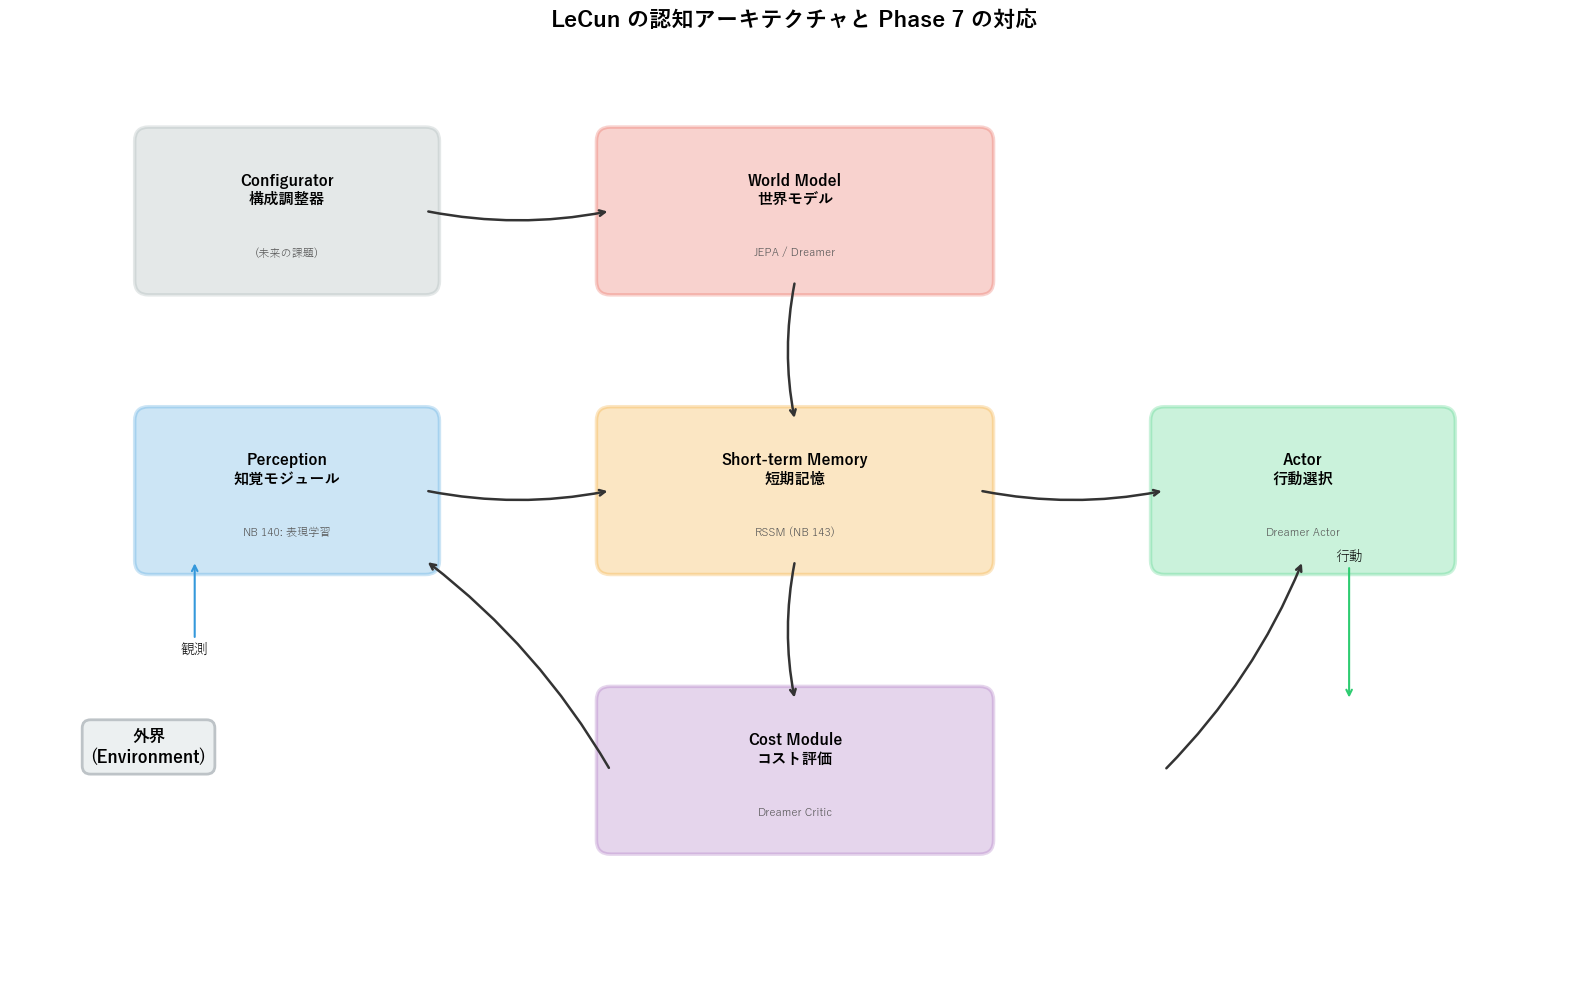

In [11]:
# ============================================================
# LeCun の認知アーキテクチャ図解
# ============================================================

def plot_lecun_architecture():
    """LeCunが提案するAGI認知アーキテクチャを図解"""
    fig, ax = plt.subplots(figsize=(16, 10))

    # モジュール: (x, y, w, h, name, color, phase7_link)
    modules = [
        (6.0, 8.0, 4.0, 1.5, 'World Model\n世界モデル',
         '#E74C3C', 'JEPA / Dreamer'),
        (1.0, 5.0, 3.0, 1.5, 'Perception\n知覚モジュール',
         '#3498DB', 'NB 140: 表現学習'),
        (6.0, 5.0, 4.0, 1.5, 'Short-term Memory\n短期記憶',
         '#F39C12', 'RSSM (NB 143)'),
        (12.0, 5.0, 3.0, 1.5, 'Actor\n行動選択',
         '#2ECC71', 'Dreamer Actor'),
        (6.0, 2.0, 4.0, 1.5, 'Cost Module\nコスト評価',
         '#9B59B6', 'Dreamer Critic'),
        (1.0, 8.0, 3.0, 1.5, 'Configurator\n構成調整器',
         '#95A5A6', '(未来の課題)'),
    ]

    for x, y, w, h, name, color, link in modules:
        rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                              facecolor=color, alpha=0.25,
                              edgecolor=color, linewidth=2.5)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h * 0.65, name,
                ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(x + w / 2, y + h * 0.2, link,
                ha='center', va='center', fontsize=8, color='#555',
                style='italic')

    # 接続矢印
    connections = [
        (4.0, 5.75, 6.0, 5.75),    # Perception -> Memory
        (8.0, 8.0, 8.0, 6.5),      # World Model -> Memory
        (10.0, 5.75, 12.0, 5.75),   # Memory -> Actor
        (8.0, 5.0, 8.0, 3.5),      # Memory -> Cost
        (6.0, 2.75, 4.0, 5.0),      # Cost -> Perception (feedback)
        (4.0, 8.75, 6.0, 8.75),    # Configurator -> World Model
        (12.0, 2.75, 13.5, 5.0),   # Cost -> Actor
    ]

    for x1, y1, x2, y2 in connections:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.8,
                                   color='#333', connectionstyle='arc3,rad=0.1'))

    # 外界
    ax.text(1.0, 3.0, '外界\n(Environment)',
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#ECF0F1',
                      edgecolor='#BDC3C7', linewidth=2))
    ax.annotate('観測', xy=(1.5, 5.0), xytext=(1.5, 4.0),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#3498DB'),
                fontsize=10, ha='center')
    ax.annotate('行動', xy=(14.0, 3.5), xytext=(14.0, 5.0),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#2ECC71'),
                fontsize=10, ha='center')

    ax.set_xlim(-0.5, 16.5)
    ax.set_ylim(0.5, 10.5)
    ax.axis('off')
    ax.set_title('LeCun の認知アーキテクチャと Phase 7 の対応',
                 fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

plot_lecun_architecture()

### 残された研究課題

世界モデルが AGI に至るには、まだ多くの課題が残されています：

#### 1. 長期的な一貫性
現在の世界モデルは **数秒から数十秒** の未来しか安定して予測できません。
人間のように数時間～数日先の計画を立てるには、**階層的な世界モデル**（異なる時間スケールで動作する複数の予測器）が必要です。

#### 2. 因果推論の統合
現在の世界モデルは **相関関係** は学習しますが、**因果関係** の理解は不十分です。
「この行動がこの結果を引き起こす」という因果的な理解を世界モデルに組み込む研究が進んでいます。

#### 3. 言語との統合
LLM（大規模言語モデル）と世界モデルの統合は、最も活発な研究分野の一つです。
テキストによる目標指定、世界モデルの状態の言語的説明、マルチモーダルな世界理解が期待されています。

#### 4. 安全性と整合性
世界モデルが高度になるほど、その予測に基づく行動の安全性が重要になります。
世界モデルの「幻覚」（実際には起こりえない予測）に対する対策が不可欠です。

#### 5. スケーラビリティ
Genie 2 (2024) は大規模な世界モデルの可能性を示しましたが、
リアルタイムでの推論や、多様な環境への汎化にはまだ課題があります。

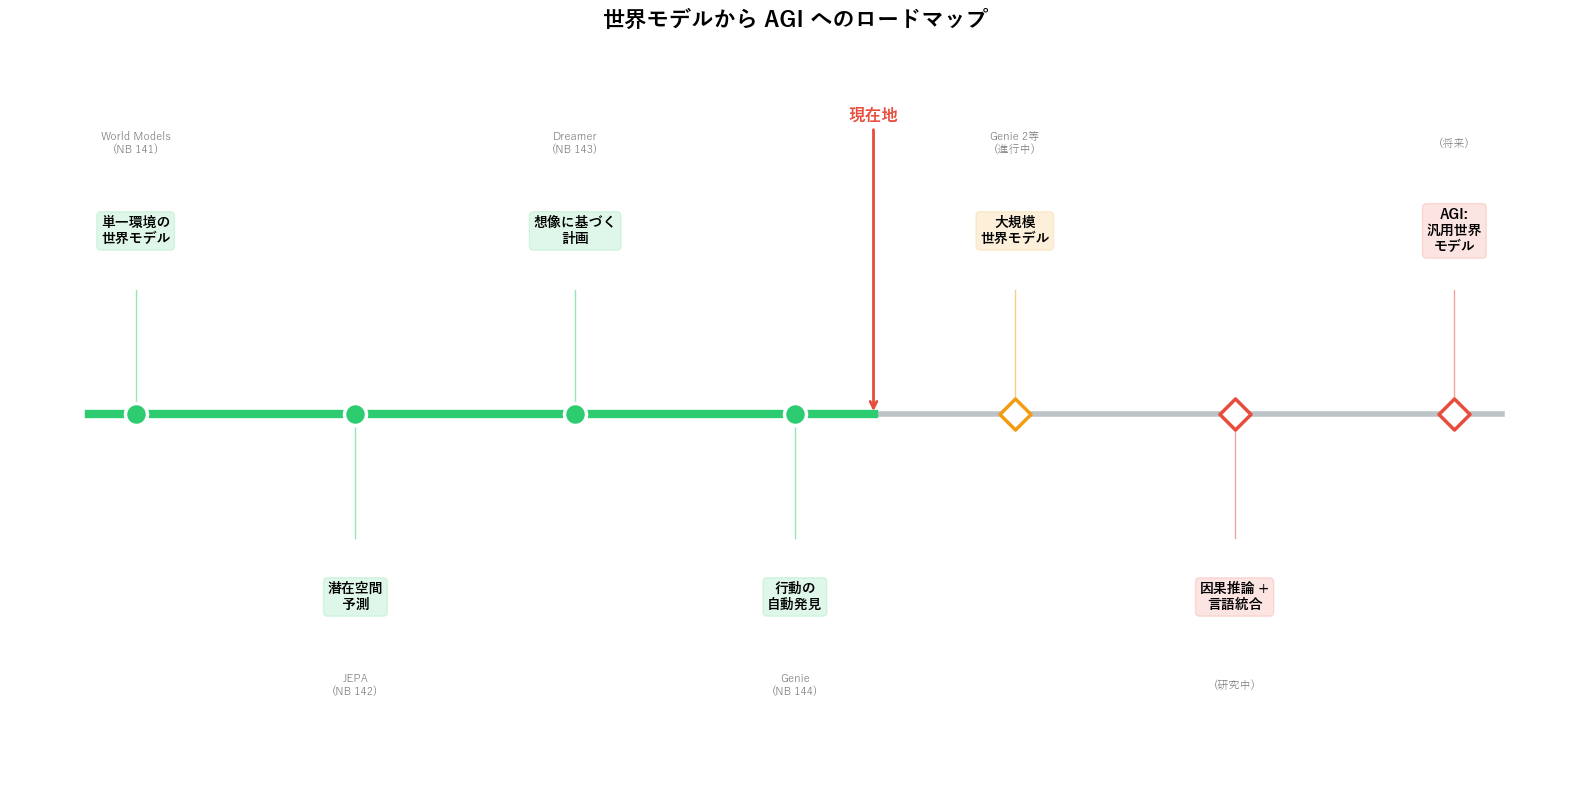

In [12]:
# ============================================================
# AGI への道のり: 現在地と今後の課題
# ============================================================

def plot_agi_roadmap():
    """世界モデルからAGIへの道のりをロードマップとして可視化"""
    fig, ax = plt.subplots(figsize=(16, 8))

    # マイルストーン
    milestones = [
        (0.08, '単一環境の\n世界モデル', '#2ECC71', True,
         'World Models\n(NB 141)'),
        (0.22, '潜在空間\n予測', '#2ECC71', True,
         'JEPA\n(NB 142)'),
        (0.36, '想像に基づく\n計画', '#2ECC71', True,
         'Dreamer\n(NB 143)'),
        (0.50, '行動の\n自動発見', '#2ECC71', True,
         'Genie\n(NB 144)'),
        (0.64, '大規模\n世界モデル', '#F39C12', False,
         'Genie 2等\n(進行中)'),
        (0.78, '因果推論 +\n言語統合', '#E74C3C', False,
         '(研究中)'),
        (0.92, 'AGI:\n汎用世界\nモデル', '#E74C3C', False,
         '(将来)'),
    ]

    # ベースライン
    ax.plot([0.05, 0.95], [0.5, 0.5], '-', color='#BDC3C7',
            linewidth=4, zorder=1)

    # 達成部分を色付き
    ax.plot([0.05, 0.55], [0.5, 0.5], '-', color='#2ECC71',
            linewidth=6, zorder=2)

    for x, label, color, achieved, detail in milestones:
        marker = 'o' if achieved else 'D'
        edge = 'white' if achieved else color
        fill = color if achieved else 'white'
        ax.scatter(x, 0.5, s=250, c=fill, edgecolors=edge,
                   linewidth=2.5, zorder=5, marker=marker)

        y_text = 0.75 if milestones.index(
            (x, label, color, achieved, detail)) % 2 == 0 else 0.25
        ax.text(x, y_text, label, ha='center', va='center',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor=color, alpha=0.15,
                          edgecolor=color))
        ax.plot([x, x], [0.5, y_text - 0.08 if y_text > 0.5 else y_text + 0.08],
                '-', color=color, linewidth=1, alpha=0.5)

        detail_y = y_text + 0.12 if y_text > 0.5 else y_text - 0.12
        ax.text(x, detail_y, detail, ha='center', va='center',
                fontsize=8, color='#777', style='italic')

    # 現在地マーカー
    ax.annotate('現在地', xy=(0.55, 0.5), xytext=(0.55, 0.9),
                fontsize=12, fontweight='bold', color='#E74C3C',
                ha='center',
                arrowprops=dict(arrowstyle='->', lw=2, color='#E74C3C'))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('世界モデルから AGI へのロードマップ',
                 fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

plot_agi_roadmap()

### 世界モデルの未来: 3つのシナリオ

世界モデル研究の今後について、3つのシナリオを考えてみましょう：

#### シナリオ A: 「万能世界モデル」
一つの巨大な世界モデルが、物理法則・社会規範・言語知識を統合的に学習し、
あらゆる環境のダイナミクスを予測できるようになる。
LLM の成功パターンに類似し、スケーリング則が鍵となる。

#### シナリオ B: 「モジュール型世界モデル」
専門化された複数の世界モデルが協調して動作する。
物理シミュレータ、社会モデル、言語モデルがそれぞれ独立に発展し、
Configurator（LeCun のアーキテクチャ）が適切に組み合わせる。

#### シナリオ C: 「ハイブリッド」
LLM（テキスト世界モデル）とビジョン世界モデルが融合し、
マルチモーダルな世界理解が実現する。現在のGPT-4V/Gemini等の方向性の延長。

いずれのシナリオでも、Phase 7 で学んだ **表現学習・潜在空間予測・想像による計画** の
基本概念は不可欠です。

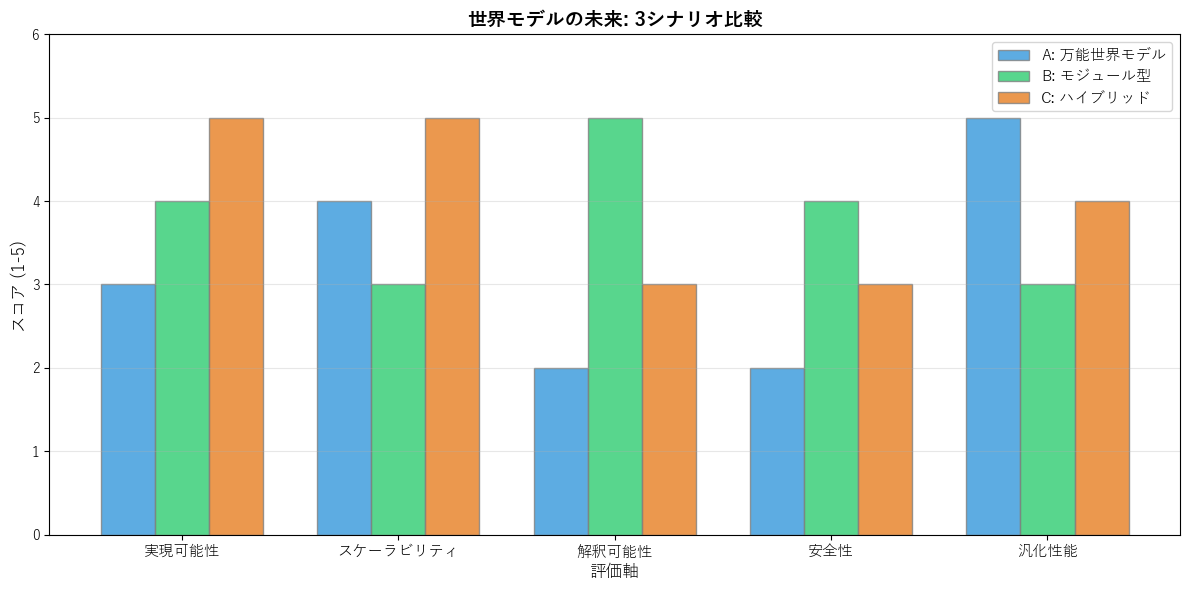

In [13]:
# ============================================================
# 3シナリオの比較チャート
# ============================================================

def plot_scenarios():
    """3つの未来シナリオをバーチャートで比較"""
    fig, ax = plt.subplots(figsize=(12, 6))

    scenarios = ['A: 万能世界モデル', 'B: モジュール型', 'C: ハイブリッド']
    metrics = ['実現可能性', 'スケーラビリティ', '解釈可能性', '安全性', '汎化性能']

    scores = np.array([
        [3, 4, 2, 2, 5],  # A
        [4, 3, 5, 4, 3],  # B
        [5, 5, 3, 3, 4],  # C
    ])

    x = np.arange(len(metrics))
    width = 0.25
    colors = ['#3498DB', '#2ECC71', '#E67E22']

    for i, (scenario, color) in enumerate(zip(scenarios, colors)):
        offset = (i - 1) * width
        ax.bar(x + offset, scores[i], width, label=scenario,
               color=color, alpha=0.8, edgecolor='gray')

    ax.set_xlabel('評価軸', fontsize=12)
    ax.set_ylabel('スコア (1-5)', fontsize=12)
    ax.set_title('世界モデルの未来: 3シナリオ比較', fontsize=14,
                 fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 6)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scenarios()

### Phase 7 の核心的洞察: 5つのキーメッセージ

Phase 7 全体を通じて最も重要な洞察を5つにまとめます：

**1. 「世界モデル = 内部シミュレータ」**
世界モデルの本質は、外界のダイナミクスを内部に再現するシミュレータです。
シミュレータの精度と効率が、知的行動の質を決めます。

**2. 「予測空間の選択がアーキテクチャを決定する」**
ピクセル空間・特徴空間・潜在行動空間のどこで予測を行うかという選択が、
モデルの全体設計を支配します。この選択は正解が一つではなく、タスク依存です。

**3. 「コラプス問題は世界モデル設計の中心課題」**
自己教師あり学習において、全ての入力に同じ表現を出力する「コラプス」は
常に存在する脅威です。EMA、VQ離散化、再構成ロスなど、各モデルが異なる戦略で対処しています。

**4. 「想像は効率的な学習の鍵」**
Dreamer が示したように、世界モデル内での「想像」は実世界での試行錯誤を
大幅に削減します。これは人間の思考過程（メンタルシミュレーション）にも通じます。

**5. 「行動は発見できる」**
Genie が示したように、行動ラベルがなくても環境の動的構造から行動空間を
自動的に発見できます。これは、AIが自律的に世界の操作方法を学ぶ可能性を示しています。

---

<a id="quiz"></a>
## 7. 総合クイズ（5問）

Phase 7 全体の理解を確認する5問のクイズです。
各問題は異なるノートブックの内容をカバーしています。

---

### Q1: 表現学習の動機 (Notebook 140)

**問題**: ピクセル空間で直接未来のフレームを予測する代わりに、
特徴空間（潜在空間）で予測を行う利点を3つ挙げてください。

<details>
<summary>答えを見る</summary>

**答え**:

1. **次元削減**: ピクセル空間（例: 256x256x3 = 196,608次元）よりも遥かに低次元の空間で予測できるため、計算効率が高い
2. **ノイズ耐性**: 背景のテクスチャや照明変化など、意味的に無関係な情報がフィルタリングされるため、予測がノイズに対して頑健になる
3. **意味的な距離の整合性**: 特徴空間ではユークリッド距離が意味的な類似度と整合するため、予測誤差が意味のある学習信号となる
</details>

---

### Q2: World Models のアーキテクチャ (Notebook 141)

**問題**: Ha & Schmidhuber の World Models は VAE + MDN-RNN + Controller の3要素で構成されます。
MDN-RNN が出力する「混合ガウス分布」は、なぜ単一のガウス分布ではなく混合分布なのですか？
世界モデルの予測タスクにおける利点を説明してください。

<details>
<summary>答えを見る</summary>

**答え**:

環境のダイナミクスは**マルチモーダル**（複数の起こりうる未来がある）場合が多いためです。
例えば、交差点に差し掛かった車は「左折」「直進」「右折」のいずれも可能です。
単一のガウス分布では平均的な（ぼやけた）予測しかできませんが、
混合ガウス分布は各モードをそれぞれ表現できるため、
マルチモーダルな未来予測が可能になります。
</details>

---

### Q3: JEPA vs 生成モデル (Notebook 142)

**問題**: JEPA はピクセルの再構成を行わないことが特徴ですが、
これは VAE や拡散モデルなどの生成モデルと比較してどのような利点がありますか？
一方で、ピクセル再構成を行わないことのデメリットは何ですか？

<details>
<summary>答えを見る</summary>

**答え**:

**利点**:
- ピクセルレベルの詳細（テクスチャ、正確な色など）を予測する必要がないため、計算コストが大幅に低い
- 意味的に無関係なピクセル詳細に惑わされず、高次の構造的・意味的な予測に集中できる
- 生成モデルの「モード崩壊」問題を回避しやすい

**デメリット**:
- 予測結果を人間が直接可視化・検証できない（潜在空間上の予測なので画像として見られない）
- 下流タスクに特化した評価が必要（線形プローブなど）
- 画像生成・動画生成のような直接的なアプリケーションには使えない
</details>

---

### Q4: Dreamer の想像に基づく計画 (Notebook 143)

**問題**: DreamerV3 の RSSM（Recurrent State-Space Model）は、
状態表現を「決定論的部分」と「確率的部分」に分けています。
なぜ完全に確率的、または完全に決定論的ではないのでしょうか？

<details>
<summary>答えを見る</summary>

**答え**:

- **決定論的部分** (GRU hidden state): 長期的な文脈を安定的に保持する役割を果たします。完全に確率的だと、長いシーケンスで情報が失われやすくなります
- **確率的部分** (離散確率変数): 環境の不確実性を明示的に表現します。同じ状態と行動からでも複数の未来がありうることをモデル化します
- **両方を組み合わせることで**: 安定した長期記憶（決定論的）と、環境の確率性（確率的）の両方を同時に捉えることができます。これにより、想像パスにおいて現実的かつ多様な未来のシミュレーションが可能になります
</details>

---

### Q5: Genie の潜在行動推定 (Notebook 144)

**問題**: Genie は動画に行動ラベルが付いていなくても、潜在行動空間を自動的に発見できます。
この「潜在行動」は、人間が定義する行動（「左に移動」「ジャンプ」等）と
どのような関係にあると期待されますか？
また、VQ-VAE による離散化が行動推定に適している理由を説明してください。

<details>
<summary>答えを見る</summary>

**答え**:

**潜在行動と人間定義行動の関係**:
- 潜在行動は人間の定義する行動と1対1対応するとは限りませんが、意味的に類似した構造を持つことが期待されます
- 例えば、「左に移動」に対応する複数の潜在コードが近い埋め込みを持つ、といった形で構造が現れます
- 環境の物理法則に基づく自然な行動分割が発見されることが多いです

**VQ-VAE による離散化の利点**:
- ゲーム等のインタラクティブ環境では行動は本質的に離散的（ボタン操作）なので、離散表現は自然
- 離散化により行動空間が有限になり、探索と計画が容易になる
- VQ のコミットメントロスがコードブックの有効活用を促し、表現のコラプスを防ぐ
</details>

In [14]:
# ============================================================
# クイズの対応ノートブック一覧
# ============================================================

def print_quiz_mapping():
    """各クイズ問題とノートブックの対応を表示"""
    print("=" * 60)
    print("総合クイズ -- ノートブック対応表")
    print("=" * 60)

    mapping = [
        ("Q1", "表現学習の動機", "140",
         "ピクセル空間 vs 特徴空間の利点"),
        ("Q2", "MDN-RNN の混合ガウス分布", "141",
         "マルチモーダルな未来予測"),
        ("Q3", "JEPA vs 生成モデル", "142",
         "ピクセル再構成をしない利点と欠点"),
        ("Q4", "RSSM の決定論的+確率的状態", "143",
         "長期記憶と不確実性の両立"),
        ("Q5", "Genie の潜在行動推定", "144",
         "VQ-VAE離散化と行動発見"),
    ]

    for q, topic, nb, focus in mapping:
        print(f"\n  {q}: {topic}")
        print(f"     対応NB: {nb} | 焦点: {focus}")

    print("\n" + "=" * 60)
    print("全問正解できれば Phase 7 の理解は十分です！")
    print("=" * 60)

print_quiz_mapping()

総合クイズ -- ノートブック対応表

  Q1: 表現学習の動機
     対応NB: 140 | 焦点: ピクセル空間 vs 特徴空間の利点

  Q2: MDN-RNN の混合ガウス分布
     対応NB: 141 | 焦点: マルチモーダルな未来予測

  Q3: JEPA vs 生成モデル
     対応NB: 142 | 焦点: ピクセル再構成をしない利点と欠点

  Q4: RSSM の決定論的+確率的状態
     対応NB: 143 | 焦点: 長期記憶と不確実性の両立

  Q5: Genie の潜在行動推定
     対応NB: 144 | 焦点: VQ-VAE離散化と行動発見

全問正解できれば Phase 7 の理解は十分です！


---

<a id="summary"></a>
## 8. まとめとチェックリスト

### Phase 7 学習チェックリスト

以下の全ての項目にチェックが入れば、Phase 7 の学習は完了です。

#### 基礎理解（Notebook 140）
- [ ] ピクセル空間予測の3つの問題点を列挙できる
- [ ] 対照学習（InfoNCE）の仕組みを説明できる
- [ ] 線形プローブ評価の目的と手順を理解している

#### 古典モデル（Notebook 141）
- [ ] VAE + MDN-RNN + Controller の役割を説明できる
- [ ] 「夢の中での訓練」の概念を理解している
- [ ] 混合ガウス分布によるマルチモーダル予測を説明できる

#### 理論（Notebook 142）
- [ ] JEPA がピクセル再構成を行わない理由を説明できる
- [ ] EMA ターゲットエンコーダによるコラプス防止を理解している
- [ ] エネルギーベースモデルとの関係を説明できる

#### 応用（Notebook 143）
- [ ] RSSM の決定論的+確率的状態の意味を説明できる
- [ ] 想像パスによる方策改善の流れを説明できる
- [ ] Actor-Critic が想像上の報酬で学習する仕組みを理解している

#### 発展（Notebook 144）
- [ ] 潜在行動推定の概念を説明できる
- [ ] VQ-VAE による離散行動コードブックの仕組みを理解している
- [ ] 行動ラベルなしの動画からインタラクティブ環境を生成する流れを説明できる

#### 評価（Notebook 145）
- [ ] FVD, LPIPS, ATC 等の評価指標を説明できる
- [ ] 世界モデルの品質を複数の軸で評価する方法を理解している

#### 統合（本 Notebook 146）
- [ ] 3つのパラダイム（ピクセル/特徴/潜在行動）の違いを比較できる
- [ ] Phase 1-7 の全カリキュラムにおける世界モデルの位置づけを説明できる
- [ ] 世界モデルから AGI への接続と残された課題を理解している

In [15]:
# ============================================================
# 最終サマリ
# ============================================================

def final_summary():
    """Phase 7の最終まとめメッセージ"""
    print("=" * 70)
    print("Phase 7 完了: 世界モデル")
    print("=" * 70)

    print("""
Phase 7「世界モデル」の全6章 + 総括を完了しました。

【習得した技術スタック】

  Notebook 140: 表現学習 / 対照学習 / 線形プローブ
  Notebook 141: VAE + MDN-RNN / 夢の中での訓練
  Notebook 142: JEPA / EMA Target / エネルギーベース解釈
  Notebook 143: RSSM / 想像パス / Actor-Critic
  Notebook 144: VQ-VAE / 潜在行動推定 / 環境生成
  Notebook 145: FVD / LPIPS / ATC / 総合評価
  Notebook 146: 3パラダイム統合 / AGI展望 (本章)

【3つのパラダイム】

  1. ピクセル空間予測:  直感的だが計算コストが高く、ノイズに弱い
  2. 特徴空間予測:      効率的で抽象的だが、可視化が困難
  3. 潜在行動空間:      行動ラベル不要だが、離散化の情報損失がある

【全カリキュラムの位置づけ】

  Phase 1 (NN基礎) → Phase 2 (CNN) → Phase 3 (系列) →
  Phase 4 (Attention) → Phase 5 (生成モデル) →
  Phase 6 (時空間) → Phase 7 (世界モデル)

  全ての Phase の知識が世界モデルの理解に集約されています。

【今後の学習指針】

  - 論文を読む: V-JEPA, DreamerV3, Genie 2 の原著論文
  - 実装する: 小規模な世界モデルを自分の環境で訓練
  - 最新動向を追う: 世界モデル + LLM の統合が最前線
""")

    print("=" * 70)
    print("  世界を理解し、想像し、計画する")
    print("  それが世界モデルであり、知能の本質です。")
    print("")
    print("  Phase 7 の全章を完走されたことを祝福します。")
    print("  ここで学んだ知識は、AGI への道のりの確かな一歩です。")
    print("=" * 70)

final_summary()

Phase 7 完了: 世界モデル

Phase 7「世界モデル」の全6章 + 総括を完了しました。

【習得した技術スタック】

  Notebook 140: 表現学習 / 対照学習 / 線形プローブ
  Notebook 141: VAE + MDN-RNN / 夢の中での訓練
  Notebook 142: JEPA / EMA Target / エネルギーベース解釈
  Notebook 143: RSSM / 想像パス / Actor-Critic
  Notebook 144: VQ-VAE / 潜在行動推定 / 環境生成
  Notebook 145: FVD / LPIPS / ATC / 総合評価
  Notebook 146: 3パラダイム統合 / AGI展望 (本章)

【3つのパラダイム】

  1. ピクセル空間予測:  直感的だが計算コストが高く、ノイズに弱い
  2. 特徴空間予測:      効率的で抽象的だが、可視化が困難
  3. 潜在行動空間:      行動ラベル不要だが、離散化の情報損失がある

【全カリキュラムの位置づけ】

  Phase 1 (NN基礎) → Phase 2 (CNN) → Phase 3 (系列) →
  Phase 4 (Attention) → Phase 5 (生成モデル) →
  Phase 6 (時空間) → Phase 7 (世界モデル)

  全ての Phase の知識が世界モデルの理解に集約されています。

【今後の学習指針】

  - 論文を読む: V-JEPA, DreamerV3, Genie 2 の原著論文
  - 実装する: 小規模な世界モデルを自分の環境で訓練
  - 最新動向を追う: 世界モデル + LLM の統合が最前線

  世界を理解し、想像し、計画する
  それが世界モデルであり、知能の本質です。

  Phase 7 の全章を完走されたことを祝福します。
  ここで学んだ知識は、AGI への道のりの確かな一歩です。


---

### 参考文献

Phase 7 全体の参考文献を整理します。

| 論文 | 対応NB | 内容 |
|------|--------|------|
| Chen et al., "SimCLR" (2020) | 140 | 対照学習の基礎 |
| Ha & Schmidhuber, "World Models" (2018) | 141 | VAE + MDN-RNN の世界モデル |
| LeCun, "A Path Towards Autonomous Machine Intelligence" (2022) | 142 | JEPA の提案とAGI展望 |
| Bardes et al., "V-JEPA" (2024) | 142 | 動画版 JEPA の実装 |
| Hafner et al., "DreamerV3" (2023) | 143 | 汎用的な世界モデル強化学習 |
| Bruce et al., "Genie" (2024) | 144 | 潜在行動の自動発見 |
| Unterthiner et al., "FVD" (2019) | 145 | 動画生成の評価指標 |
| Zhang et al., "LPIPS" (2018) | 145 | 知覚的画像類似度 |

---

### 次のステップ

Phase 7 を完了し、世界モデルの全体像を把握しました。次に進むための選択肢：

- **深掘り**: 各モデル（JEPA, Dreamer, Genie）の原著論文を精読し、実装の細部を理解する
- **実践**: OpenAI Gym や DMControl 等の環境で、自分だけの世界モデルを訓練する
- **最前線へ**: Genie 2, SORA, Cosmos World Foundation Model 等の最新研究を追う
- **融合**: LLM + 世界モデルのマルチモーダルアプローチを探究する

世界モデルの旅は、ここから始まります。